In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

# Load the dataset
data = pd.read_csv('netflix_dataset.csv')

print(" First 10 rows of the dataset:")
print(data.head(10))

print("\n Shape of the dataset:")
print(data.shape)


 First 10 rows of the dataset:
  show_id             title     type  release_year        genre country  \
0   s0001   Netflix Title 1    Movie          2010  Documentary   India   
1   s0002   Netflix Title 2    Movie          2023        Drama     USA   
2   s0003   Netflix Title 3    Movie          2016  Documentary   Spain   
3   s0004   Netflix Title 4  TV Show          2010      Romance   Japan   
4   s0005   Netflix Title 5    Movie          2016      Romance   India   
5   s0006   Netflix Title 6  TV Show          2018      Romance     USA   
6   s0007   Netflix Title 7  TV Show          2012       Sci-Fi   India   
7   s0008   Netflix Title 8  TV Show          2016  Documentary     USA   
8   s0009   Netflix Title 9    Movie          2017      Romance     USA   
9   s0010  Netflix Title 10  TV Show          2015       Action   India   

   rating  duration_min  views_millions  
0     6.1            77           184.4  
1     5.4            89           126.8  
2     8.2        

In [3]:
print("Missing values in the dataset:")
print(data.isnull().sum())

duplicate_rows = data.duplicated().sum()
print(f"\nNumber of duplicate rows in the dataset: {duplicate_rows}")
data = data.drop_duplicates()

# Data Cleaning and Preprocessing
# By removing duplicates and handling missing values, we ensure that the dataset is clean and ready for analysis. This step is crucial to avoid any biases or inaccuracies in the results.

Missing values in the dataset:
show_id           0
title             0
type              0
release_year      0
genre             0
country           0
rating            0
duration_min      0
views_millions    0
dtype: int64

Number of duplicate rows in the dataset: 0


In [4]:
print("Stastistical summary of the dataset:")
print(data.describe())

print("views_millions column:")
print("Maximum Value of views_millions:",data["views_millions"].max())
print("Minimum Value of views_millions:",data["views_millions"].min())
print("Average Value of views_millions:",data["views_millions"].mean())
print("median Value of views_millions:",data["views_millions"].median())
print("\n duration_min column:")
print("Maximum value of duration_min:",data["duration_min"].max())
print("Minimum value of duration_min:",data["duration_min"].min())
print("Average value of duration_min:",data["duration_min"].mean())
print("median value of duration_min:",data["duration_min"].median())

print("\n rating column:")
print("Maximum value of rating:",data["rating"].max())
print("Minimum value of rating:",data["rating"].min())
print("Average value of rating:",data["rating"].mean())
print("median value of rating:",data["rating"].median())

Stastistical summary of the dataset:
       release_year      rating  duration_min  views_millions
count    100.000000  100.000000    100.000000      100.000000
mean    2017.250000    7.212000    118.120000      128.775000
std        4.515685    1.285842     33.573462       73.078645
min     2010.000000    5.000000     62.000000        2.400000
25%     2013.000000    6.075000     89.000000       68.550000
50%     2017.500000    7.100000    116.000000      129.150000
75%     2021.000000    8.325000    145.250000      189.825000
max     2025.000000    9.500000    180.000000      249.600000
views_millions column:
Maximum Value of views_millions: 249.6
Minimum Value of views_millions: 2.4
Average Value of views_millions: 128.77499999999998
median Value of views_millions: 129.15

 duration_min column:
Maximum value of duration_min: 180
Minimum value of duration_min: 62
Average value of duration_min: 118.12
median value of duration_min: 116.0

 rating column:
Maximum value of rating: 9.5
Min

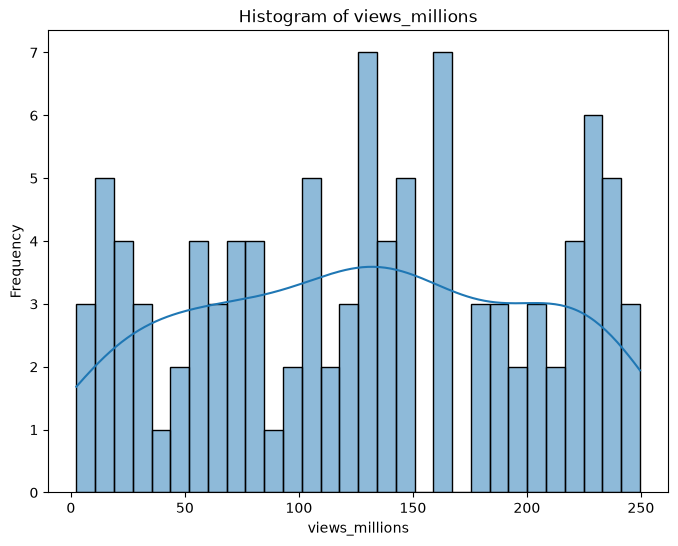

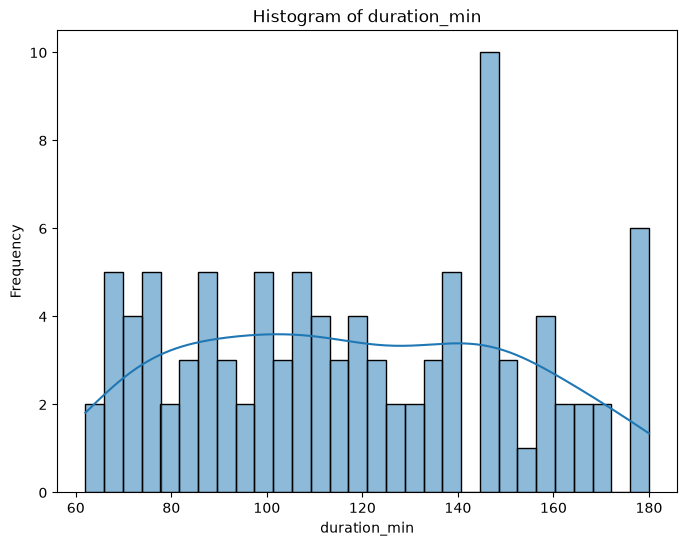

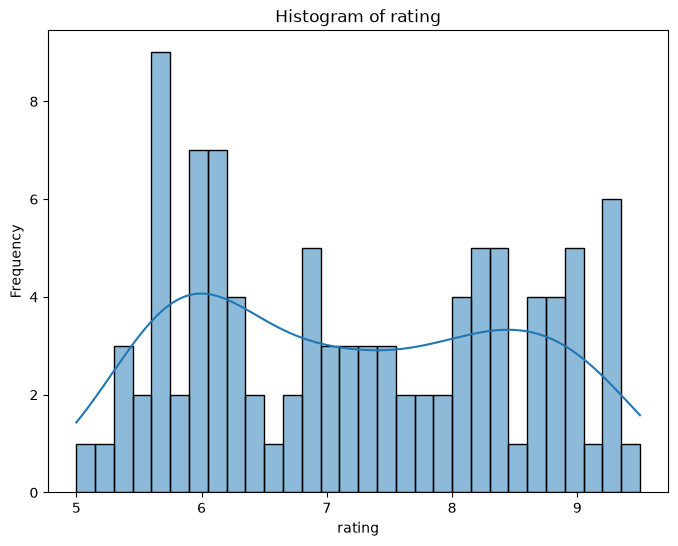

In [6]:
def plot_histograms(data):
    columns = ['views_millions', 'duration_min', 'rating']
    for column in columns:
        plt.figure(figsize=(8, 6))
        sns.histplot(data[column], bins=30, kde=True)
        plt.title(f'Histogram of {column}')
        plt.xlabel(column)
        plt.ylabel('Frequency')
        plt.show() 
plot_histograms(data) 

# Findings:
# The histograms provide insights into the distribution of the 'views_millions', 'duration_min', and 'rating' columns. We can observe the frequency of different values in these columns, which helps us understand the characteristics of the dataset better.  
# The 'views_millions' column shows the distribution of views in millions, the 'duration_min' column shows the distribution of content duration in minutes, and the 'rating' column shows the distribution of ratings. These visualizations can help identify patterns, trends, and potential outliers in the data.


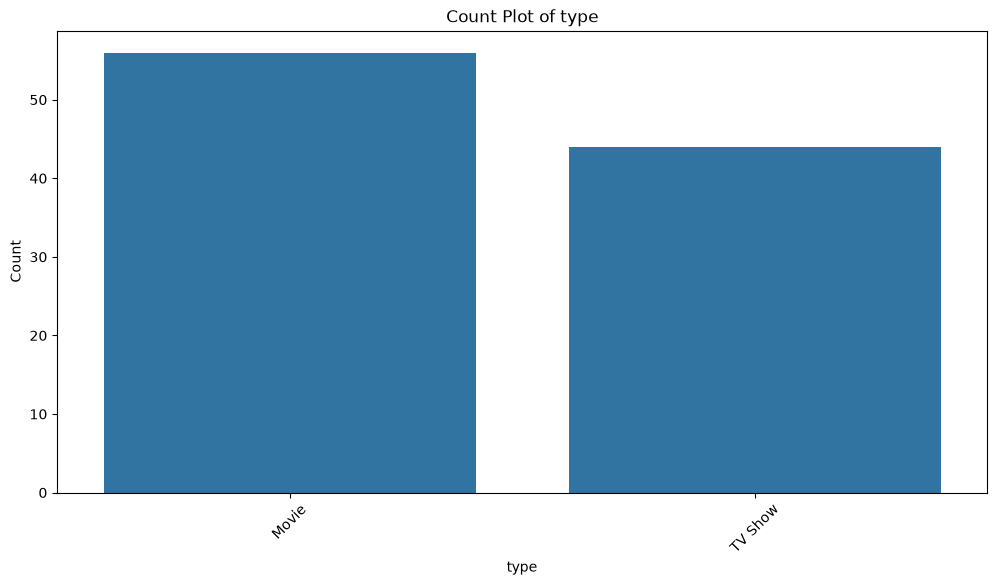

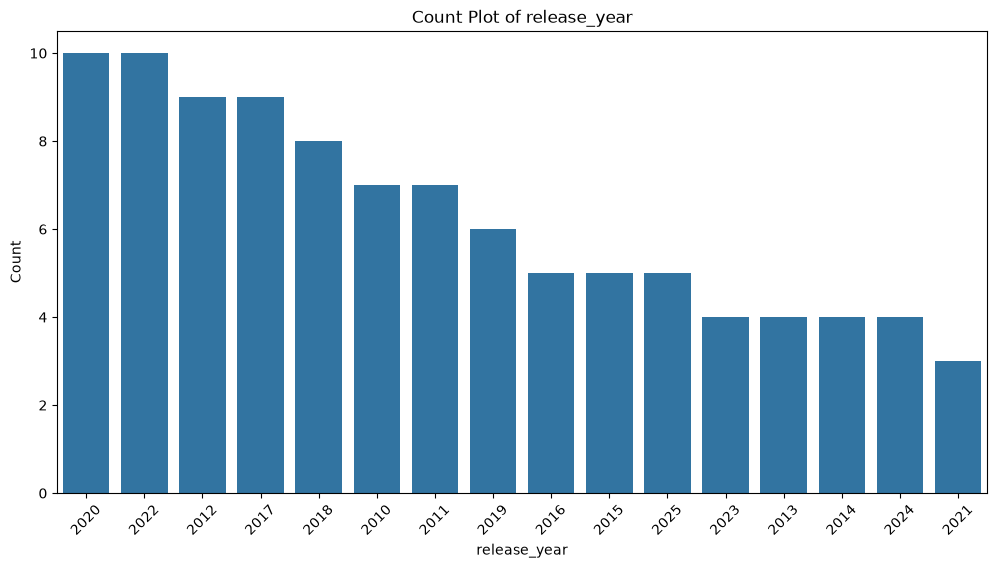

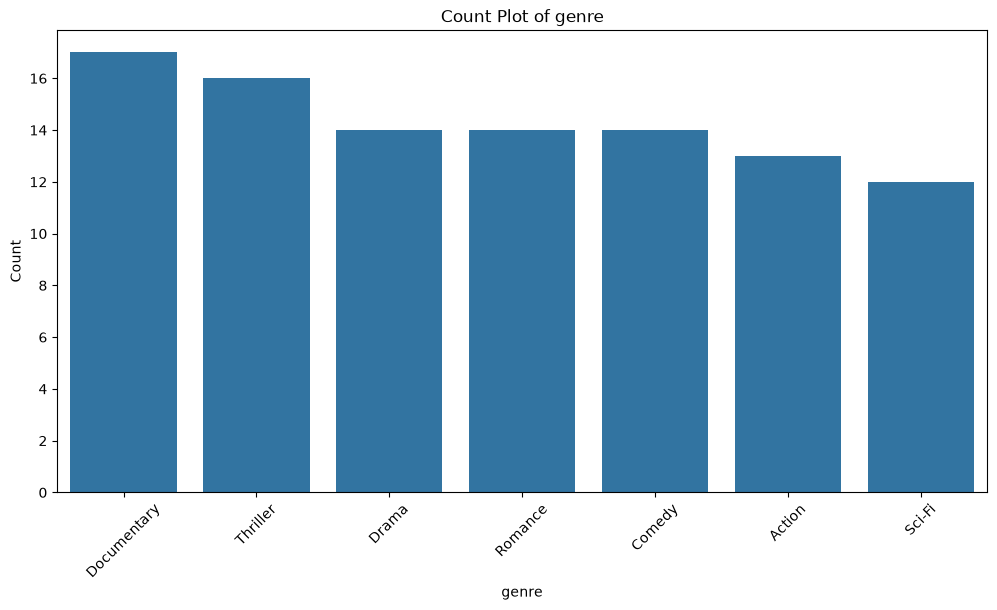

In [8]:
def plot_countplots(data):
    columns = ['type', 'release_year', 'genre']
    for column in columns:
        plt.figure(figsize=(12, 6))
        sns.countplot(data=data, x=column, order=data[column].value_counts().index)
        plt.title(f'Count Plot of {column}')
        plt.xlabel(column)
        plt.ylabel('Count')
        plt.xticks(rotation=45)
        plt.show()
plot_countplots(data)

# Findings:
# The count plots provide insights into the distribution of categorical variables in the dataset. We can observe the frequency of different categories in the 'type', 'release_year', and 'genre' columns.
# The 'type' column shows the distribution of content types (e.g., Movie, TV Show), the 'release_year' column shows the distribution of content release years, and the 'genre' column shows the distribution of content genres. These visualizations can help identify popular content types, trends in release years, and preferred genres among viewers.

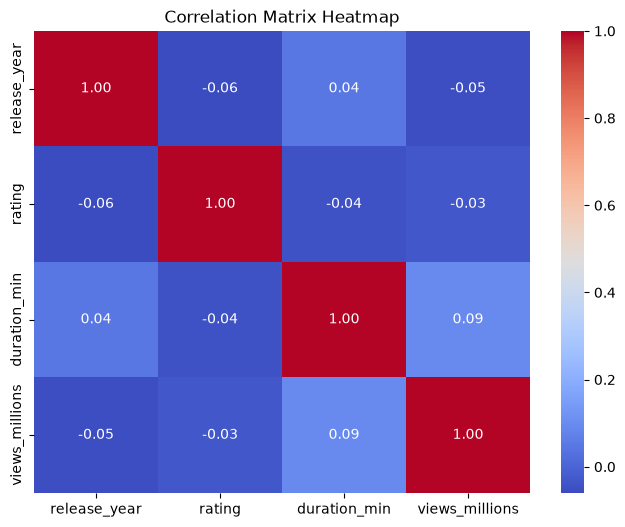

Correlation with rating:
rating            1.000000
views_millions   -0.034348
duration_min     -0.044209
release_year     -0.060191
Name: rating, dtype: float64


In [11]:
# Select only numeric columns
numeric_data = data.select_dtypes(include=['int64', 'float64'])

# Create correlation matrix
corr_matrix = numeric_data.corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")

# Title
plt.title("Correlation Matrix Heatmap")

# Show plot
plt.show()

# Display correlation with rating
print("Correlation with rating:")
print(corr_matrix["rating"].sort_values(ascending=False))

# Observations:
# The heatmap provides a visual representation of the correlation between numeric variables in the dataset. We can observe how strongly each variable is related to others, with values closer to 1 or -1 indicating stronger positive or negative correlations, respectively.
# The correlation with the 'rating' column shows how other numeric variables are related to the ratings. A positive correlation indicates that as one variable increases, the other tends to increase as well, while a negative correlation indicates an inverse relationship. This information can be useful for understanding factors that may influence content ratings on Netflix.
# By analyzing the correlation matrix, we can identify potential predictors for content ratings and make informed decisions for further analysis or modeling.   



In [13]:
# Independent Features (X)
X = data[['views_millions', 'duration_min', 'type', 'release_year', 'genre']]

# Dependent Feature (y)
y = data['rating']

# Reasoning:
# The independent features (X) are selected based on their potential influence on the dependent feature (y), which is the 'rating' of the content. The features 'eviews_millions', 'duration_min', 'type', 'release_year', and 'genre' are chosen as they can provide insights into how different factors affect the ratings of Netflix content.
# The dependent feature (y) is the 'rating' column, which represents the ratings given to the content. By analyzing the relationship between the independent features and the dependent feature, we can gain a better understanding of what factors contribute to higher or lower ratings on Netflix.

In [14]:
print("Categorical Features Before Encoding:")
print(data[['type']].head())

encoded_features = pd.get_dummies(data[['type']])
print("\nCategorical Features After Encoding:")
print(encoded_features.head())

Categorical Features Before Encoding:
      type
0    Movie
1    Movie
2    Movie
3  TV Show
4    Movie

Categorical Features After Encoding:
   type_Movie  type_TV Show
0        True         False
1        True         False
2        True         False
3       False          True
4        True         False


In [15]:
from sklearn.preprocessing import StandardScaler
# Select numeric independent features
X = data[['views_millions', 'duration_min', 'release_year']]

# Create StandardScaler object
scaler = StandardScaler()

# Apply scaling
X_scaled = scaler.fit_transform(X)

# Convert scaled data into a DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Display first 5 rows
print("First 5 rows of Scaled Data:")
print(X_scaled.head())


First 5 rows of Scaled Data:
   views_millions  duration_min  release_year
0        0.765001     -1.230947     -1.613603
1       -0.027162     -0.871721      1.279754
2       -1.002237     -0.153270     -0.278207
3       -0.592403     -0.123334     -1.613603
4       -1.425824     -0.302947     -0.278207


  show_id            title     type  release_year        genre country  \
0   s0001  Netflix Title 1    Movie          2010  Documentary   India   
1   s0002  Netflix Title 2    Movie          2023        Drama     USA   
2   s0003  Netflix Title 3    Movie          2016  Documentary   Spain   
3   s0004  Netflix Title 4  TV Show          2010      Romance   Japan   
4   s0005  Netflix Title 5    Movie          2016      Romance   India   

   rating  duration_min  views_millions  
0     6.1            77           184.4  
1     5.4            89           126.8  
2     8.2           113            55.9  
3     5.7           114            85.7  
4     5.5           108            25.1  

Missing Values:
show_id           0
title             0
type              0
release_year      0
genre             0
country           0
rating            0
duration_min      0
views_millions    0
dtype: int64

Duplicate Rows: 0


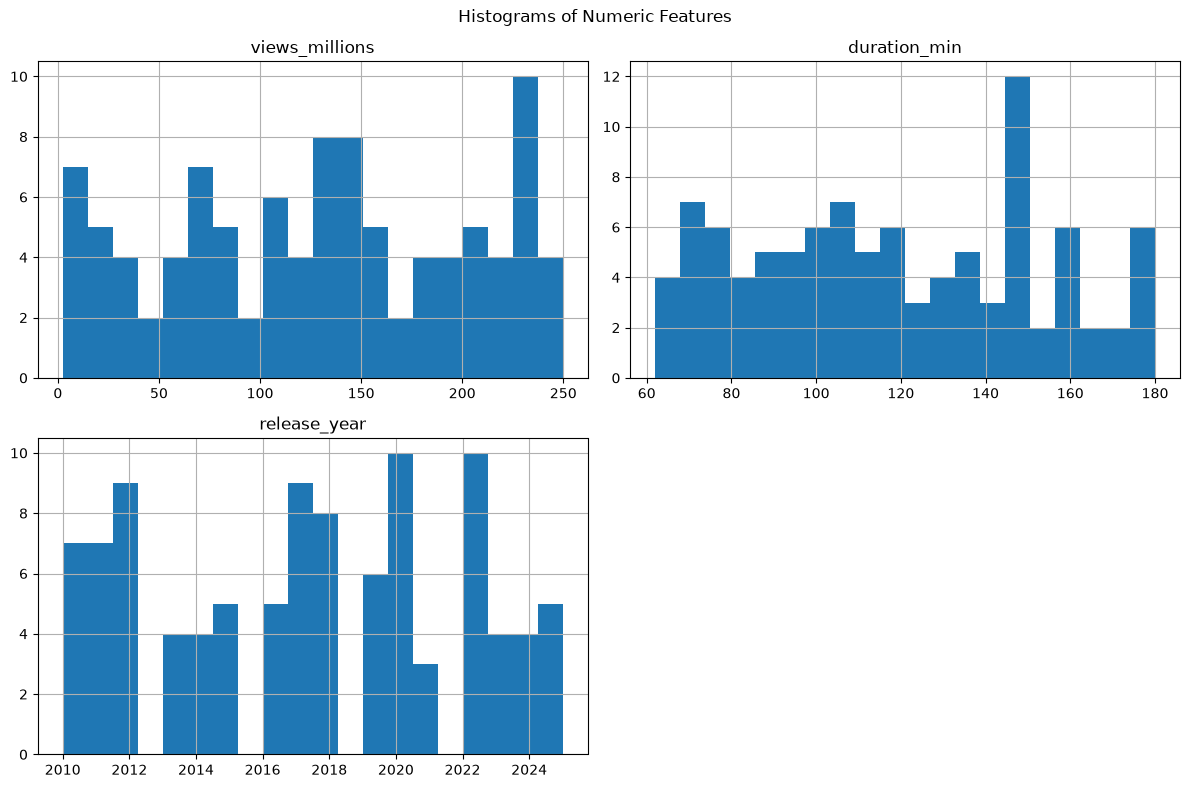

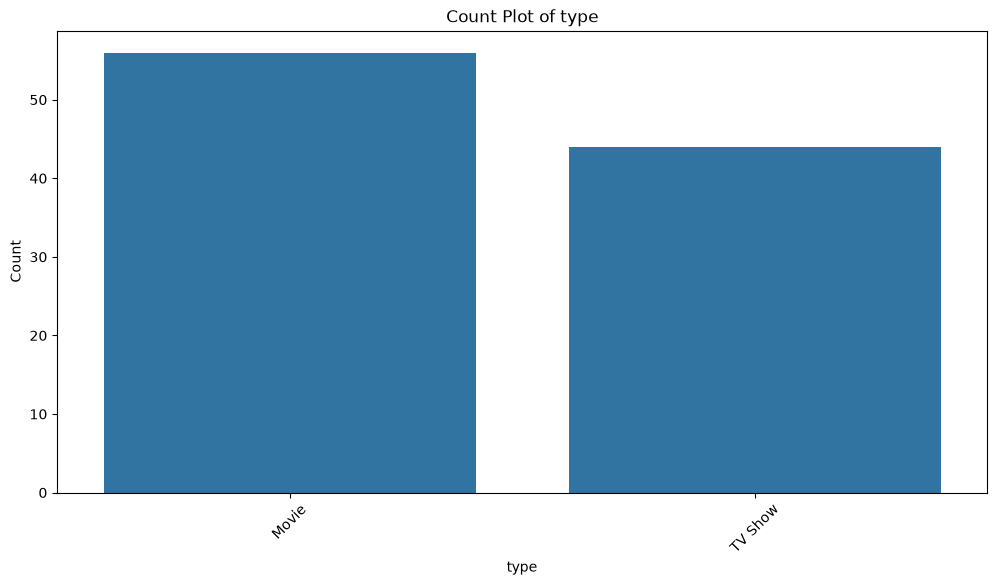

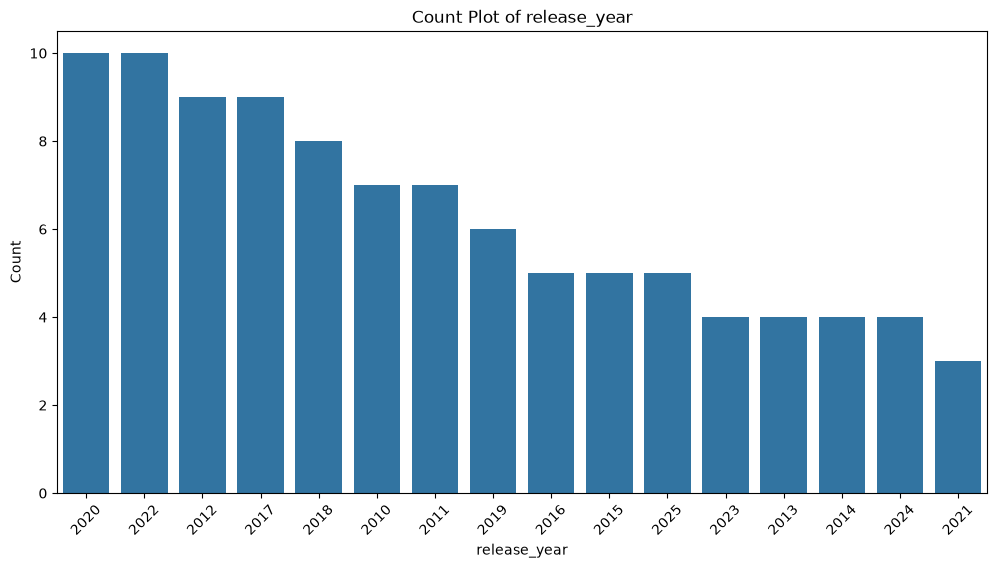

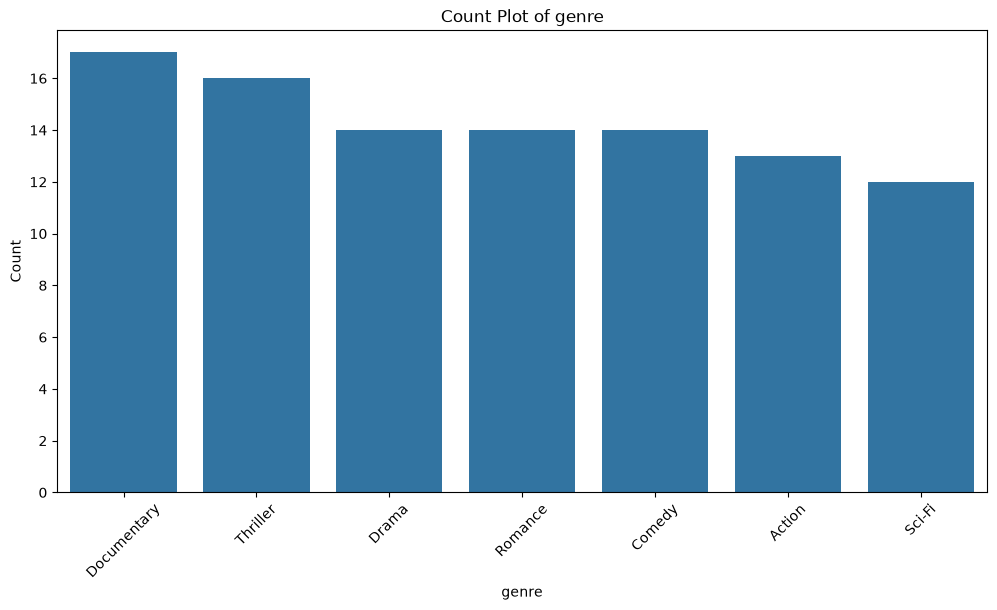

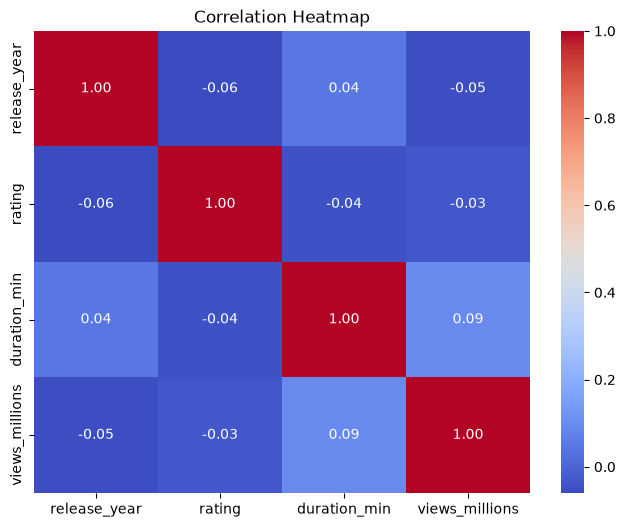


Independent Features:
Index(['show_id', 'title', 'type', 'release_year', 'genre', 'country',
       'duration_min', 'views_millions'],
      dtype='str')

Dependent Feature:
rating

Encoded Data:
  show_id            title country  duration_min  views_millions  \
0   s0001  Netflix Title 1   India            77           184.4   
1   s0002  Netflix Title 2     USA            89           126.8   
2   s0003  Netflix Title 3   Spain           113            55.9   
3   s0004  Netflix Title 4   Japan           114            85.7   
4   s0005  Netflix Title 5   India           108            25.1   

   type_TV Show  release_year_2011  release_year_2012  release_year_2013  \
0         False              False              False              False   
1         False              False              False              False   
2         False              False              False              False   
3          True              False              False              False   
4         Fals

In [18]:
# Display first 5 rows
print(data.head())

# Check missing values
print("\nMissing Values:")
print(data.isnull().sum())

# Remove missing values
data.dropna(inplace=True)

# Check duplicate values
print("\nDuplicate Rows:", data.duplicated().sum())

# Remove duplicates
data.drop_duplicates(inplace=True)

# --------------------------
# 2. Exploratory Data Analysis (EDA)
# --------------------------

# Histogram of Numeric Features
numeric_cols = ['views_millions', 'duration_min', 'release_year']

data[numeric_cols].hist(figsize=(12,8), bins=20)
plt.suptitle("Histograms of Numeric Features")
plt.tight_layout()
plt.show()

# Count Plots for Categorical Features
def plot_countplots(data):
    columns = ['type', 'release_year', 'genre']
    for column in columns:
        plt.figure(figsize=(12, 6))
        sns.countplot(data=data, x=column, order=data[column].value_counts().index)
        plt.title(f'Count Plot of {column}')
        plt.xlabel(column)
        plt.ylabel('Count')
        plt.xticks(rotation=45)
        plt.show()
plot_countplots(data)

# Correlation Heatmap
plt.figure(figsize=(8,6))

corr = data.select_dtypes(include=['int64','float64']).corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

# --------------------------
# 3. Input and Output Features
# --------------------------

X = data.drop("rating", axis=1)
y = data["rating"]

print("\nIndependent Features:")
print(X.columns)

print("\nDependent Feature:")
print(y.name)

# --------------------------
# 4. Encode Categorical Variables
# --------------------------

X = pd.get_dummies(
    X,
    columns=['type', 'release_year', 'genre'],
    drop_first=True
)

print("\nEncoded Data:")
print(X.head())

# --------------------------
# 5. Scale Numeric Features
# --------------------------

scaler = StandardScaler()

numeric_features = [ 'views_millions', 'duration_min']

X[numeric_features] = scaler.fit_transform(X[numeric_features])

print("\nFirst 5 Rows of Scaled Data:")
print(X.head())

# --------------------------
# Project Completed
# --------------------------
print("\nPreprocessing Pipeline Completed Successfully!")